
# Actividad 1 — La imagen como arreglo numérico

Antes de entrenar cualquier CNN (ver `actividad_3_clasificacion_visual_cnn.ipynb`), este notebook
revisa cómo se representa una imagen como arreglo numérico y qué propiedades hay que verificar antes
de pasarla a un modelo: ancho, alto, canales, orden BGR/RGB, escala de grises, `dtype`, rango de
intensidades, normalización y memoria — para prevenir errores de color, dimensiones y escala que
producen resultados que *parecen* válidos pero son técnicamente incorrectos.

Cada sección es un checkpoint independiente, mapeado directamente a un criterio de la rúbrica.



## Checkpoint 0 — Imagen usada: fuente y condiciones de uso

La imagen es un frame de video de pádel **grabado por el autor** para este mismo proyecto (mismo
material usado en `actividad_3_clasificacion_visual_cnn.ipynb`) — no es una imagen de terceros, así
que no aplica ninguna licencia externa ni atribución: uso propio, sin restricciones.

- **Fuente**: captura propia del autor, video de pádel grabado para este proyecto.
- **Archivo**: `data/Padel_an_2-6/test/images/Punto_1_mp4-0000_jpg...jpg` (frame extraído con Roboflow).
- **Condiciones de uso**: material propio, libre de restricciones de terceros.


In [1]:

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

def find_repo_root(start=None):
    p = Path(start or Path.cwd())
    for _ in range(5):
        if (p / "data.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("No se encontró data.yaml subiendo desde " + str(start))

ROOT = find_repo_root()
IMG_PATH = ROOT / "data" / "Padel_an_2-6" / "test" / "images" / \
    "Punto_1_mp4-0000_jpg.rf.1f2275227317eaa948c1b86fe466e957.jpg"
print("Imagen:", IMG_PATH)
print("Existe:", IMG_PATH.exists())


Imagen: c:\Users\luisj\OneDrive\Documentos\Maestria Inteligencia Artificial\Tercer Semestre\Primer Ciclo\Tecnicas_Avanzadas_Modelado_En_IA\Unidad_2\padel-impact-position-detection\data\Padel_an_2-6\test\images\Punto_1_mp4-0000_jpg.rf.1f2275227317eaa948c1b86fe466e957.jpg
Existe: True



## Checkpoint 1 — Inspección con OpenCV: shape, dtype, rango y memoria

*(Criterio: "Se reportan shape, dtype, rango y tamaño de la imagen")*

`cv2.imread` devuelve un arreglo NumPy `(alto, ancho, canales)` — **no** `(ancho, alto, canales)`, un
error de lectura frecuente. El tamaño en memoria (`nbytes`) debe coincidir exactamente con
`alto × ancho × canales × bytes_por_pixel` (1 byte por canal para `uint8`).


In [2]:

img_bgr = cv2.imread(str(IMG_PATH))  # OpenCV lee en BGR, no RGB

alto, ancho, canales = img_bgr.shape
print(f"shape (alto, ancho, canales): {img_bgr.shape}")
print(f"dtype: {img_bgr.dtype}")
print(f"valor mínimo / máximo: {img_bgr.min()} / {img_bgr.max()}")
print(f"canales: {canales}")
print(f"tamaño en memoria: {img_bgr.nbytes:,} bytes ({img_bgr.nbytes/1024:.1f} KB)")

esperado = alto * ancho * canales * img_bgr.itemsize
print(f"verificación: alto*ancho*canales*itemsize = {esperado:,} bytes  ->  {'coincide' if esperado==img_bgr.nbytes else 'NO coincide'}")


shape (alto, ancho, canales): (640, 640, 3)
dtype: uint8
valor mínimo / máximo: 0 / 255
canales: 3
tamaño en memoria: 1,228,800 bytes (1200.0 KB)
verificación: alto*ancho*canales*itemsize = 1,228,800 bytes  ->  coincide



## Checkpoint 2 — Comparación con otra librería: orden de canales BGR vs RGB

*(Criterio: "Se distingue correctamente el orden de canales BGR y RGB")*

`cv2.imread` carga los canales en orden **BGR** (Blue-Green-Red) por una decisión histórica de diseño
de OpenCV. La mayoría de las demás librerías (PIL/Pillow, matplotlib, y lo que espera casi cualquier
CNN preentrenada) usan **RGB**. Si no se convierte explícitamente, los colores quedan invertidos
(rojo↔azul) — la imagen se *ve* como una foto válida, pero está mal.


In [3]:

img_pil = Image.open(IMG_PATH)  # PIL/Pillow lee directo en RGB
img_pil_arr = np.array(img_pil)

px = (320, 320)  # punto con color real (el (0,0) cae en la banda negra del video)
print("OpenCV  (cv2.imread)      -> shape:", img_bgr.shape, f" pixel {px} en BGR:", img_bgr[px])
print("PIL     (Image.open)     -> shape:", img_pil_arr.shape, f" mismo pixel en RGB:", img_pil_arr[px])

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # conversión explícita BGR -> RGB
print("\ncv2.cvtColor(BGR2RGB) vs. lectura directa de PIL, ¿coinciden los valores?",
      np.array_equal(img_rgb, img_pil_arr))


OpenCV  (cv2.imread)      -> shape: (640, 640, 3)  pixel (320, 320) en BGR: [184 130  97]
PIL     (Image.open)     -> shape: (640, 640, 3)  mismo pixel en RGB: [ 97 130 184]

cv2.cvtColor(BGR2RGB) vs. lectura directa de PIL, ¿coinciden los valores? True



## Checkpoint 3 — Visualizaciones correctamente rotuladas

*(Criterio: "Las visualizaciones conservan colores y proporciones correctas")*

Se muestran, lado a lado y con título explícito: la imagen BGR mostrada **sin convertir** (el error
típico: se ve "casi bien" pero con los colores invertidos) contra la versión **RGB correcta**. Ambas
mantienen la proporción original de la imagen (`aspect='equal'`, sin estirar ancho/alto).


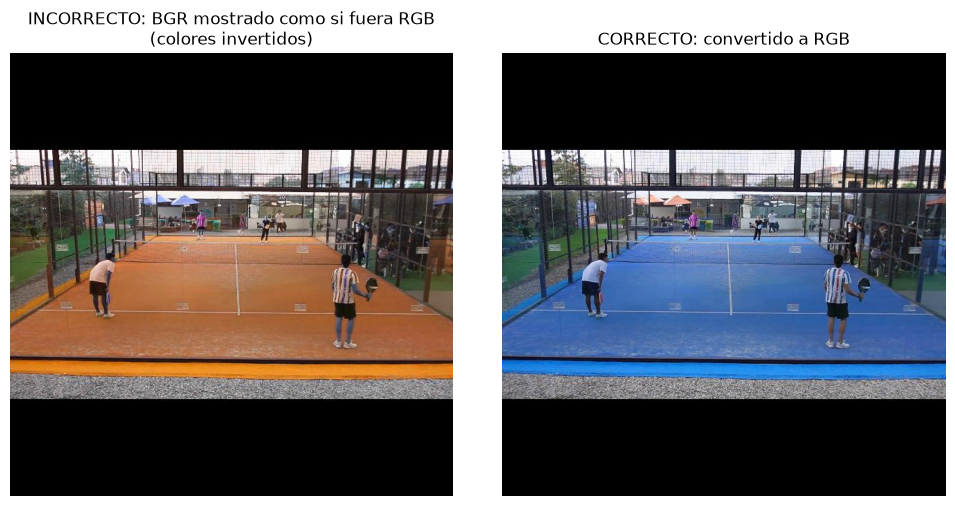

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_bgr)  # error deliberado: array BGR interpretado como RGB por matplotlib
axes[0].set_title("INCORRECTO: BGR mostrado como si fuera RGB\n(colores invertidos)")
axes[0].axis("off")

axes[1].imshow(img_rgb)
axes[1].set_title("CORRECTO: convertido a RGB")
axes[1].axis("off")

plt.tight_layout()
plt.show()



## Checkpoint 4 — Escala de grises (con justificación)

*(Parte del criterio: "La conversión a escala de grises y la normalización están justificadas")*

Convertir a escala de grises reduce 3 canales a 1, bajando el costo de cómputo y memoria — útil cuando
el color no aporta información relevante para la tarea (p. ej. detectar bordes o formas). OpenCV usa
una combinación ponderada de R, G y B (aprox. `0.299·R + 0.587·G + 0.114·B`, que imita la sensibilidad
del ojo humano a cada color) en vez de un promedio simple.


shape: (640, 640)  (perdió la dimensión de canales)
dtype: uint8  min/max: 0 / 255


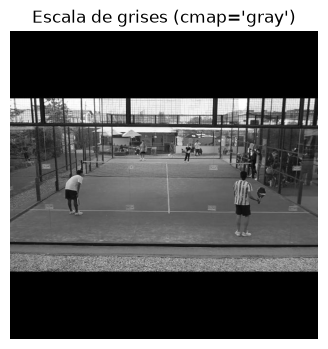

In [5]:

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
print("shape:", img_gray.shape, " (perdió la dimensión de canales)")
print("dtype:", img_gray.dtype, " min/max:", img_gray.min(), "/", img_gray.max())

plt.figure(figsize=(4, 4))
plt.imshow(img_gray, cmap="gray")  # cmap="gray" es obligatorio: sin esto, matplotlib usa un colormap falso
plt.title("Escala de grises (cmap='gray')")
plt.axis("off")
plt.show()



## Checkpoint 5 — Normalización (con justificación)

*(Parte del criterio: "La conversión a escala de grises y la normalización están justificadas")*

Las redes neuronales entrenan mejor (gradientes más estables, convergencia más rápida) cuando la
entrada tiene una escala pequeña y consistente, en vez de enteros `uint8` en [0, 255]. Se normaliza a
`float32` en el rango [0, 1] dividiendo por 255 — la normalización más simple y la que se usa como base
antes de, opcionalmente, estandarizar con media/desvío de un dataset (p. ej. ImageNet).


In [6]:

img_norm = img_rgb.astype(np.float32) / 255.0
print("dtype original:", img_rgb.dtype, " rango:", img_rgb.min(), "-", img_rgb.max())
print("dtype normalizado:", img_norm.dtype, " rango:", img_norm.min(), "-", round(img_norm.max(), 4))


dtype original: uint8  rango: 0 - 255
dtype normalizado: float32  rango: 0.0 - 1.0



## Checkpoint 6 — Tensor de entrada para una CNN

*(Criterio: "Se relaciona la representación con el formato de entrada de una CNN")*

OpenCV/NumPy/PIL representan una imagen como `(alto, ancho, canales)` — formato **HWC**. Frameworks
como PyTorch esperan `(batch, canales, alto, ancho)` — formato **NCHW**, `float32`, valores ya
normalizados. Hay que **transponer** los ejes (no solo "reshape") y agregar la dimensión de lote.


In [7]:

tensor_chw = np.transpose(img_norm, (2, 0, 1))       # HWC -> CHW
tensor_nchw = tensor_chw[np.newaxis, ...]            # agrega dimensión de batch -> NCHW

print("HWC  (imagen normal):     ", img_norm.shape)
print("CHW  (canales primero):   ", tensor_chw.shape)
print("NCHW (batch de 1, listo para una CNN):", tensor_nchw.shape, tensor_nchw.dtype)
print("rango:", tensor_nchw.min(), "-", round(tensor_nchw.max(), 4))


HWC  (imagen normal):      (640, 640, 3)
CHW  (canales primero):    (3, 640, 640)
NCHW (batch de 1, listo para una CNN): (1, 3, 640, 640) float32
rango: 0.0 - 1.0



## Checkpoint 7 — Errores comunes de representación

*(Criterio: "Se identifican errores comunes de dimensiones, canales o escala")*

Tres errores frecuentes, cada uno con evidencia concreta:

1. **Canales invertidos (BGR vs RGB)**: ya mostrado en el Checkpoint 3 — mostrar/entrenar con una
   imagen BGR sin convertir da colores incorrectos sin que el código lance ningún error.
2. **Escala sin normalizar**: pasar `uint8` en [0, 255] a un modelo que espera `float32` en [0, 1] no
   rompe el código (ambos son arreglos numéricos válidos), pero la magnitud de la entrada es ~255x
   más grande de lo esperado, saturando activaciones y arruinando el entrenamiento.
3. **Orden de dimensiones (HWC vs CHW)**: usar `.reshape()` en vez de `.transpose()` para pasar de HWC
   a CHW **no** da un error de forma (el shape final es el mismo), pero mezcla los píxeles de forma
   incorrecta — la imagen queda irreconocible aunque el tensor "parezca" válido.


Pixel (320, 320) sin normalizar (uint8): [ 97 130 184]
Pixel (320, 320) normalizado (float32):    [0.38039216 0.50980395 0.72156864]
Diferencia de magnitud: ~255x


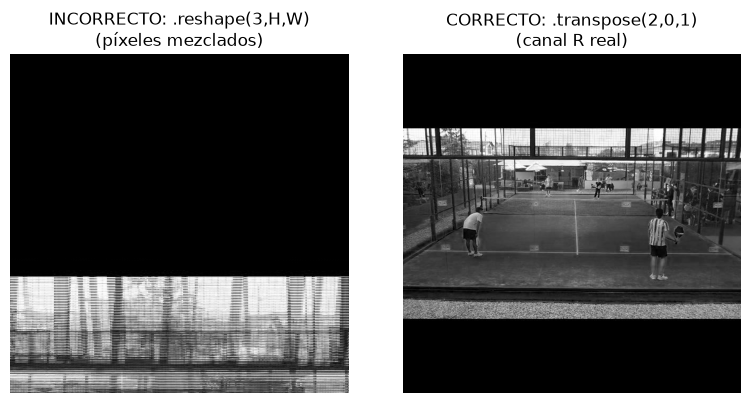

In [8]:

# Error 2, evidencia numérica: mismo pixel, dos escalas muy distintas
px = (320, 320)  # mismo punto con color real usado en el Checkpoint 2
print(f"Pixel {px} sin normalizar (uint8):", img_rgb[px])
print(f"Pixel {px} normalizado (float32):   ", img_norm[px])
print(f"Diferencia de magnitud: ~{img_rgb[px].astype(float).mean() / (img_norm[px].mean()+1e-9):.0f}x")

# Error 3, evidencia visual: reshape (mal) vs transpose (bien)
mal_chw = img_norm.reshape(3, img_norm.shape[0], img_norm.shape[1])  # INCORRECTO: mezcla los pixeles
bien_chw = np.transpose(img_norm, (2, 0, 1))                          # CORRECTO

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mal_chw[0], cmap="gray")
axes[0].set_title("INCORRECTO: .reshape(3,H,W)\n(píxeles mezclados)")
axes[0].axis("off")
axes[1].imshow(bien_chw[0], cmap="gray")
axes[1].set_title("CORRECTO: .transpose(2,0,1)\n(canal R real)")
axes[1].axis("off")
plt.tight_layout()
plt.show()



## Checkpoint 8 — Resumen

| Propiedad | Valor |
|---|---|
| Fuente de la imagen | captura propia del autor (video de pádel del proyecto) |
| Shape original (HWC, BGR) | ver Checkpoint 1 |
| dtype original | `uint8`, rango [0, 255] |
| Orden de canales al leer con OpenCV | BGR (requiere `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)`) |
| Escala de grises | 1 canal, misma resolución, ponderación 0.299R+0.587G+0.114B |
| Normalización | `float32`, rango [0, 1] (÷255) |
| Tensor de entrada para CNN | NCHW `float32` en [0, 1] |
| Errores comunes cubiertos | canales invertidos, escala sin normalizar, HWC/CHW con reshape incorrecto |

Advertencia final: ningún error de esta lista rompe el código — todos producen un arreglo NumPy
"válido" que solo falla al comparar contra lo que el modelo (o el ojo humano) realmente espera.
